# 01 — EPMA, basaltic glasses (session 20/12/2016)

Input: `outputs/interim/glass_*.csv` from notebook 00. Output: a filtered spot table, a per-sample average table, precision/accuracy tables and four figures.

Every filtering or correction decision is stated with its reason in the markdown cell above the code that does it — those cells are the methodology section.

In [17]:
# --- config ---
from pathlib import Path
import sys, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

ROOT = Path.cwd()
INTERIM = ROOT / "outputs" / "interim"
STEP = "glass" 
OUT = ROOT / "outputs" / STEP; FIG = ROOT / "figures" / STEP
for d in (OUT, FIG): d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))
from geohelpers import q_test, summarize, load_ref_majors

OX = ["SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO", "CaO", "Na2O", "K2O", "P2O5", "SO3", "Cl", "F"]
MAJ = OX[:10]                      # majors + minors with reference values
TRACE = ["SO3", "Cl", "F", "P2O5", "MnO"]   # low-concentration, checked against detection limits
SAVE = True
pd.set_option("display.width", 200, "display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 9})

gl = (pd.read_csv(INTERIM / "glass_oxide.csv")
        .merge(pd.read_csv(INTERIM / "glass_meta.csv", parse_dates=["datetime"])[["No.", "datetime", "curr_A"]],
               on="No."))
intens = pd.read_csv(INTERIM / "glass_intensity.csv")
ref = load_ref_majors(ROOT / "data" / "Standards.xlsx")
gl["minutes"] = (gl.datetime - gl.datetime.min()).dt.total_seconds() / 60
print(gl.shape, "| standards:", gl.is_std.sum(), "| sample spots:", (~gl.is_std).sum())

(105, 23) | standards: 24 | sample spots: 81


## 1. Run structure

The session is not a flat list: the four standards were run twice each at the start, once in the middle and once at the end. That gives three **standard brackets** and two sample batches, which is what makes a batch-wise drift assessment possible at all.

In [18]:
gl["bracket"] = np.select([gl["No."] <= 8, gl["No."].between(54, 61), gl["No."] >= 98], [1, 2, 3], np.nan)
gl["batch"]   = np.where(gl["No."].between(9, 53), 1, np.where(gl["No."].between(62, 97), 2, np.nan))

print(gl.groupby("bracket")["No."].agg(["min", "max", "count"]).to_string())
print(gl.groupby("batch")["No."].agg(["min", "max", "count"]).to_string())
print("\nsession length: %.1f h, %.1f min between analyses"
      % (gl.minutes.max() / 60, gl.minutes.diff().median()))

         min  max  count
bracket                 
1.0        1    8      8
2.0       54   61      8
3.0       98  105      8
       min  max  count
batch                 
1.0      9   53     45
2.0     62   97     36

session length: 6.0 h, 3.0 min between analyses


## 2. Precision

Repeatability of each standard over the whole session (n = 6 each, spread across the three brackets, so this is *session* reproducibility and not within-bracket repeatability — the conservative number to quote).

In [19]:
prec = summarize(gl[gl.is_std], OX, "material")
prec_w = prec.pivot(index="oxide", columns="material", values="2RSD%").reindex(OX)
print("2RSD % per standard\n")
print(prec_w.round(1).to_string())
print("\ntotals:")
print(gl[gl.is_std].groupby("material")["Total"].agg(["mean", "std", "min", "max"]).round(2).to_string())

2RSD % per standard

material    KE3  Scapolite    VG2  VGA99
oxide                                   
SiO2        2.4        0.5    1.8    1.8
TiO2       10.8      220.0    2.3    1.8
Al2O3       1.3        1.4    2.8    4.0
FeO         5.4       77.4    2.5    2.7
MnO        52.8      118.9   37.8   28.7
MgO        83.1      230.5    2.1    1.5
CaO        12.1        1.2    1.1    1.1
Na2O       57.1        4.1    6.8    8.8
K2O         2.4        4.0    6.5    0.5
P2O5      155.4      230.0   26.5   18.0
SO3        48.8        6.0    5.2   87.9
Cl          4.2        1.8   31.0   47.1
F          27.5      244.2  150.2   88.8

totals:
             mean   std     min     max
material                               
KE3         99.47  0.69   98.17   99.96
Scapolite   99.72  0.34   99.37  100.11
VG2        101.12  0.62  100.00  101.73
VGA99       99.66  0.81   98.52  100.68


Precision splits cleanly by concentration, as it should: everything above ~1 wt% reproduces at 1–4 % 2RSD, everything below ~0.5 wt% at tens of %. Two results are not just a concentration effect and matter later:

* **Na₂O in KE3: 57 % 2RSD** (mean 5.6 wt%, so not a low-concentration problem). KE3 is a rhyolitic glass and Na migrates away from the beam within the first seconds of counting; with Na counted first and for only 10 s this is alkali loss, not poor statistics. The basaltic standards do not show it (VG2 6.8 %, VGA99 8.8 %), because Na mobility is far lower in a depolymerised basaltic melt. Flagged here because the samples are basaltic — so the KE3 behaviour does not propagate to them — but it does mean **F, which is calibrated on KE3, sits on a standard that is visibly unstable under the beam**.
* **F and SO₃ scatter at 30–90 % 2RSD in all four standards.** Neither is quantitative in this session at basaltic concentrations.

## 3. Accuracy

Deviation of each standard's session mean from its reference value in `Standards.xlsx`. The sheet reports sulphur as element S, so it is converted to SO₃ (× 2.4972) in the loader — comparing measured SO₃ against an S value would have produced a spurious −60 % error.

The lecture criterion: an oxide is **a problem where |accuracy error| > precision (2SD)**, i.e. the deviation cannot be explained by the scatter of the measurement.

In [20]:
rows = []
for m, g in gl[gl.is_std].groupby("material"):
    for ox in OX:
        rv = ref.loc[m, ox] if ox in ref.columns else np.nan
        mu, sd2 = g[ox].mean(), 2 * g[ox].std()
        rows.append(dict(standard=m, oxide=ox, reference=rv, measured=mu, sd2=sd2,
                         dev=mu - rv, dev_pct=100 * (mu - rv) / rv,
                         problem=abs(mu - rv) > sd2 if pd.notna(rv) else np.nan))
acc = pd.DataFrame(rows)

for m in ["VGA99", "VG2", "Scapolite", "KE3"]:
    print(f"===== {m}")
    print(acc[acc.standard == m].drop(columns="standard").round(3).to_string(index=False), "\n")

===== VGA99
oxide  reference  measured   sd2    dev  dev_pct problem
 SiO2     50.940    51.035 0.930  0.095    0.186   False
 TiO2      4.060     4.082 0.074  0.022    0.534   False
Al2O3     12.490    12.288 0.489 -0.202   -1.615   False
  FeO     13.300    13.432 0.366  0.132    0.990   False
  MnO      0.150     0.199 0.057  0.049   32.956   False
  MgO      5.080     5.190 0.077  0.110    2.165    True
  CaO      9.300     9.353 0.100  0.053    0.573   False
 Na2O      2.660     2.750 0.242  0.090    3.383   False
  K2O      0.820     0.814 0.004 -0.006   -0.671    True
 P2O5      0.380     0.394 0.071  0.014    3.732   False
  SO3      0.042     0.031 0.027 -0.011  -26.977   False
   Cl      0.027     0.024 0.011 -0.003  -10.677   False
    F        NaN     0.062 0.055    NaN      NaN     NaN 

===== VG2
oxide  reference  measured   sd2    dev  dev_pct problem
 SiO2     50.810    51.245 0.929  0.435    0.856   False
 TiO2      1.850     1.858 0.043  0.008    0.450   False
Al2O3  

Reading this correctly depends on what each standard *is* in this session (from the `_std-cnd` file, notebook 00):

* **VGA99 calibrates nine of the thirteen oxides**, so its "accuracy" is close to circular — it mainly tests whether the instrument still reproduces the values it was standardised against. It does, to well within 1 % for SiO₂, TiO₂, CaO, K₂O and FeO. MgO is the exception at **+2.2 %**, and K₂O trips the problem criterion only because its precision is exceptional (2SD = 0.004 wt%, deviation −0.7 %) — a good illustration that the criterion flags *statistical* significance, not geological significance, and both belong in the write-up.
* **VG-2 is the honest accuracy check**: a basaltic glass of near-identical matrix that calibrates nothing. Majors land within 1 % (SiO₂ +0.9 %, TiO₂ +0.5 %, Al₂O₃ −0.9 %, FeO +0.3 %), which is the headline number for data quality. **MgO is +6.1 % and exceeds 2SD**, and CaO is +1.6 %, also above 2SD.
* **Scapolite is off by 2–3 % on SiO₂, Al₂O₃ and CaO, exactly as the .docx warns** — it is a different matrix analysed with a basalt-calibrated ZAF correction. That is expected behaviour, not an instrument fault, and it is not evidence against the sample data. Scapolite is only there for SO₃ and Cl, which it reproduces within 0.7 %.
* **KE3 has reference values only for Cl, F and S**, so F accuracy rests on a single standard that is also its own calibrant. No independent check on F exists in this session.

**The one real accuracy problem is MgO: +6 % on VG-2 and +2 % on VGA99, both beyond precision, both in the same direction.** Since Mg is calibrated on VGA99 and VGA99 itself reads high, the offset is in the Mg calibration rather than in a single standard. One plausible cause is visible in `_std-cnd`: the Mg standard intensity dates from **17 Nov 2016**, five weeks before the session, whereas Si and Al were re-standardised on the session day (20 Dec) and are the two most accurate oxides here. Na (24 Nov) and K/P/Ti (17 Nov) also sit among the larger deviations — though Fe (16 Sep) is excellent, so the correlation is suggestive rather than proven. Present it as a hypothesis in the report.

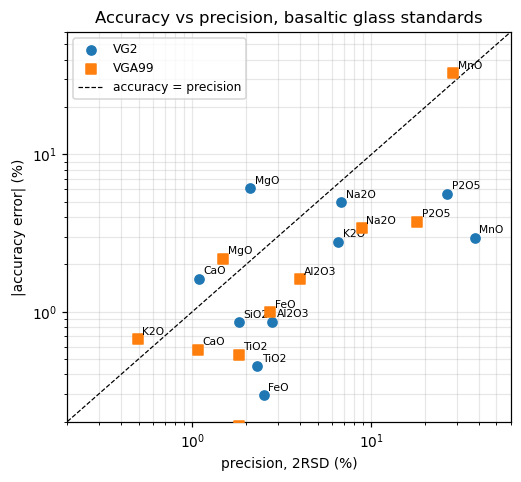

In [21]:
# Figure 2 — accuracy against precision, per oxide, for the two basaltic standards
fig, ax = plt.subplots(figsize=(5.2, 4.6))
for m, mk, c in [("VG2", "o", "tab:blue"), ("VGA99", "s", "tab:orange")]:
    d = acc[(acc.standard == m) & acc.reference.notna() & acc.oxide.isin(MAJ)]
    ax.scatter(200 * d.sd2 / 2 / d.measured, d.dev_pct.abs(), marker=mk, c=c, label=m, zorder=3)
    for _, r in d.iterrows():
        ax.annotate(r.oxide, (200 * r.sd2 / 2 / r.measured, abs(r.dev_pct)),
                    fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [0.2, 60]
ax.plot(lim, lim, "k--", lw=0.8, label="accuracy = precision")
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel="precision, 2RSD (%)", ylabel="|accuracy error| (%)",
       title="Accuracy vs precision, basaltic glass standards")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")
if SAVE: fig.savefig(FIG / "fig02_accuracy_vs_precision_glass.png")
plt.show()

Points above the 1:1 line are the problem oxides — the deviation from the reference value is larger than the measurement can explain. MgO sits clearly above it for both standards; everything else falls on or below the line, i.e. limited by precision rather than biased.

## 4. Drift

Three brackets over six hours. Two questions, in order: is there a trend, and would correcting for it make the data better?

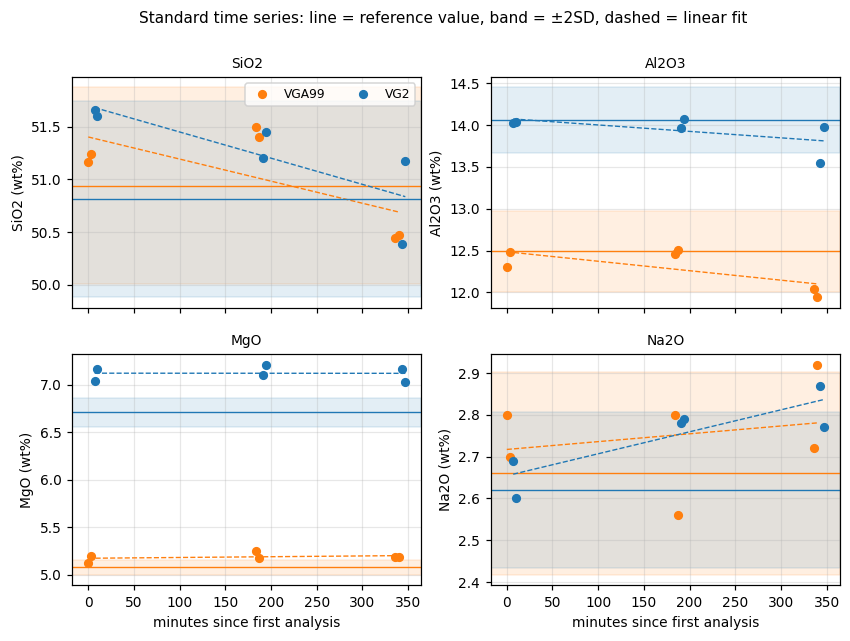


change over the whole session, % of the mean (fit), vs precision:
       VGA99   VG2  2RSD%_VG2
SiO2    -1.5  -1.7        1.8
TiO2     0.7   2.4        2.3
Al2O3   -3.3  -2.0        2.8
FeO     -2.4  -0.0        2.5
MnO     -7.3 -34.8       37.8
MgO      0.6  -0.0        2.1
CaO      0.5  -1.0        1.1
Na2O     2.5   6.9        6.8
K2O     -0.0   2.4        6.5
P2O5     9.9  23.9       26.5


In [22]:
SHOW = ["SiO2", "Al2O3", "MgO", "Na2O"]
fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
for ax, ox in zip(axs.ravel(), SHOW):
    for m, c in [("VGA99", "tab:orange"), ("VG2", "tab:blue")]:
        d = gl[gl.material == m]
        ax.plot(d.minutes, d[ox], "o", ms=5, color=c, label=m, zorder=3)
        rv, sd = ref.loc[m, ox], d[ox].std()
        ax.axhline(rv, color=c, lw=0.9)
        ax.axhspan(rv - 2 * sd, rv + 2 * sd, color=c, alpha=.12)
        b, a = np.polyfit(d.minutes, d[ox], 1)
        ax.plot(d.minutes, b * d.minutes + a, "--", color=c, lw=0.9)
    ax.set_ylabel(f"{ox} (wt%)"); ax.grid(alpha=.3)
    ax.set_title(ox, fontsize=9)
for ax in axs[1]: ax.set_xlabel("minutes since first analysis")
axs[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle("Standard time series: line = reference value, band = ±2SD, dashed = linear fit", fontsize=10)
if SAVE: fig.savefig(FIG / "fig01_drift_glass.png")
plt.show()

slopes = pd.DataFrame({m: {ox: 100 * np.polyfit(gl[gl.material == m].minutes, gl[gl.material == m][ox], 1)[0]
                                * gl.minutes.max() / gl[gl.material == m][ox].mean() for ox in MAJ}
                       for m in ["VGA99", "VG2"]})
slopes["2RSD%_VG2"] = prec_w["VG2"]
print("\nchange over the whole session, % of the mean (fit), vs precision:")
print(slopes.round(1).to_string())

SiO₂ falls by ~1.5 % and Al₂O₃ by ~2–3 % over the six hours, in **both** standards and in the same direction, so it is instrument behaviour and not one bad standard mount; Na₂O rises by 2–7 %. Every one of those changes is, however, of the same size as the 2RSD of the oxide concerned — the trend is real but it is not resolved above the noise.

Before correcting, test whether the correction actually helps: derive k = reference/measured from **VGA99** in each bracket, apply it to the **VG-2** analyses of that same bracket, and see whether VG-2's accuracy improves. VG-2 is independent of the calibration, so this is a fair test of the correction rather than a circular one.

In [23]:
WELL = ["SiO2", "TiO2", "Al2O3", "FeO", "MgO", "CaO", "Na2O", "K2O"]   # >1 wt%, 2RSD < 10 %
k = pd.DataFrame({b: ref.loc["VGA99", MAJ] / g[MAJ].mean()
                  for b, g in gl[gl.material == "VGA99"].groupby("bracket")})
raw = gl[gl.material == "VG2"].groupby("bracket")[MAJ].mean()
cert = ref.loc["VG2", MAJ]
before = 100 * (raw - cert) / cert
after = 100 * (raw * k.T - cert) / cert

print("drift factors k = VGA99 reference / VGA99 measured"); print(k.round(4).to_string())
print("\nVG-2 deviation (%) before correction"); print(before.round(2).to_string())
print("\nVG-2 deviation (%) after bracket-wise correction"); print(after.round(2).to_string())
print("\nmean |deviation| before -> after")
print("  all 10 oxides:            %.2f -> %.2f %%" % (before.abs().values.mean(), after.abs().values.mean()))
print("  well-determined majors:   %.2f -> %.2f %%" % (before[WELL].abs().values.mean(), after[WELL].abs().values.mean()))
print("  per oxide (majors):"); print((after[WELL].abs().mean() - before[WELL].abs().mean()).round(2).to_string())

drift factors k = VGA99 reference / VGA99 measured
          1.0     2.0     3.0
SiO2   0.9949  0.9901  1.0096
TiO2   0.9975  0.9951  0.9915
Al2O3  1.0081  1.0004  1.0417
FeO    0.9830  0.9819  1.0061
MnO    0.7052  0.8099  0.7485
MgO    0.9835  0.9741  0.9788
CaO    0.9979  0.9920  0.9931
Na2O   0.9673  0.9925  0.9433
K2O    1.0074  1.0050  1.0079
P2O5   1.0237  0.9384  0.9350

VG-2 deviation (%) before correction
         SiO2  TiO2  Al2O3   FeO    MnO   MgO   CaO  Na2O   K2O   P2O5
bracket                                                               
1.0      1.61 -0.81  -0.18  0.76  10.09  5.89  2.02  0.95  2.29 -16.75
2.0      1.01  0.81  -0.32 -0.72   3.16  6.63  1.80  6.30  1.37  -4.32
3.0     -0.06  1.35  -2.10  0.84 -22.11  5.81  1.03  7.63  4.68   4.22

VG-2 deviation (%) after bracket-wise correction
         SiO2  TiO2  Al2O3   FeO    MnO   MgO   CaO  Na2O   K2O   P2O5
bracket                                                               
1.0      1.10 -1.05   0.63 -0.95 -

**The bracket factors separate into a trending part and a constant part, and only the first is drift.**

* SiO₂ (k = 0.995 → 0.990 → 1.010) and Al₂O₃ (1.008 → 1.000 → 1.042) change **between** brackets: that is the time-dependent drift, and it is of the same size as the 2RSD of those oxides.
* MgO (0.984 → 0.974 → 0.979) and K₂O (1.007 → 1.005 → 1.008) are constant across all three brackets: that is a fixed calibration offset which has nothing to do with time.

Applying the factors improves the mean absolute deviation of the independent VG-2 over the well-determined majors from 2.37 % to 1.92 %, but almost all of that gain is MgO (−2.3 %) and Na₂O (−1.8 %) — the constant offsets — while FeO and K₂O get worse. Over all ten oxides the correction is actively harmful (3.92 % → 5.14 %), because MnO and P₂O₅ are near their detection limits and their k values are noise.

**Decisions:**

1. **No time-dependent drift correction is applied.** The trend is real and coherent in both standards, but it is not resolved above the 2RSD of the oxides it affects, and each k rests on only two VGA99 analyses, so applying it would transfer the standard's noise onto every sample. It is instead absorbed into the quoted uncertainties, which are session-wide 2SD rather than within-bracket.
2. **The constant MgO offset is reported, not corrected.** Correcting it means rescaling every sample by a factor derived from one secondary standard (VG-2: 6.71/7.12 = 0.942). That is a 6 % shift in MgO — enough to move every point on a Harker diagram — so it is quoted as a known bias and the uncorrected values are reported, with the factor stated so a reader can apply it. Say this explicitly in the methods: MgO is accurate to ~+6 %, everything else to ~1 %.

## 5. Filtering the sample spots

Two separate criteria, applied in this order and counted separately:

1. **Analytical total outside 98–102 wt%.** Low totals in volcanic glass are often real — dissolved H₂O and CO₂ are not analysed, and all Fe is reported as FeO when some is Fe³⁺ — so a low total is a flag, not proof of a bad analysis. A *high* total has no such excuse: it means the matrix correction or the beam conditions were wrong for that spot.
2. **Element-specific contamination**: a spot that hit a crystal or a crystal margin instead of clean glass. In these samples that shows as low Al₂O₃ with high MgO and CaO (clinopyroxene) or high MgO with low CaO (olivine).

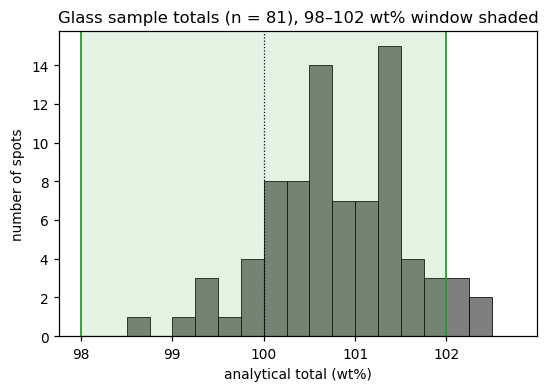

median 100.78  mean 100.81  range 98.68–102.48

outside 98–102 wt%:
 No.            sample  spot    Total
  32         UnknA-C21   6.0 102.1791
  50  UnknA-C22-PS1-L3   6.0 102.2801
  65 UnknA-BatokeCS1-3   4.0 102.4753
  72     UnknA-Flow1-1   2.0 102.1020
  86     UnknA-Flow1-2   7.0 102.2002


In [24]:
smp = gl[~gl.is_std].copy()

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.hist(smp.Total, bins=np.arange(98, 103, 0.25), color="tab:grey", edgecolor="k", lw=.5)
ax.axvspan(98, 102, color="tab:green", alpha=.12)
for x in (98, 102): ax.axvline(x, color="tab:green", lw=1.2)
ax.axvline(100, color="k", lw=.8, ls=":")
ax.set(xlabel="analytical total (wt%)", ylabel="number of spots",
       title=f"Glass sample totals (n = {len(smp)}), 98–102 wt% window shaded")
if SAVE: fig.savefig(FIG / "fig03_totals_glass.png")
plt.show()

print("median %.2f  mean %.2f  range %.2f–%.2f" % (smp.Total.median(), smp.Total.mean(), smp.Total.min(), smp.Total.max()))
print("\noutside 98–102 wt%:")
print(smp.loc[~smp.Total.between(98, 102), ["No.", "sample", "spot", "Total"]].to_string(index=False))

Only five of 81 spots fall outside the window, and all five are **above** it (102.1–102.5 wt%); the median is 100.8. A distribution centred 0.8 wt% high, with the standards themselves at 99.5–101.1, points at the same calibration offset that MgO showed rather than at bad spots — so the five high totals are rejected as individual analyses, but the systematic offset is reported as a data-quality statement, not corrected away.

In [25]:
# contamination screen: a glass spot that is really a crystal
sus = smp[(smp.Al2O3 < 10) | (smp.MgO > 8) | (smp.CaO > 15)]
print("spots failing the crystal screen (Al2O3 < 10, MgO > 8 or CaO > 15 wt%):")
print(sus[["No.", "sample", "spot", "SiO2", "Al2O3", "FeO", "MgO", "CaO", "Na2O", "K2O", "Total"]].round(2).to_string(index=False))

smp["fail_total"] = ~smp.Total.between(98, 102)
smp["fail_crystal"] = smp["No."].isin(sus["No."])

spots failing the crystal screen (Al2O3 < 10, MgO > 8 or CaO > 15 wt%):
 No.           sample  spot  SiO2  Al2O3  FeO   MgO   CaO  Na2O  K2O  Total
  49 UnknA-C22-PS1-L3   5.0 48.11    6.4 7.38 13.83 23.28   0.4  0.0 101.99


One spot, **No. 49 (UnknA-C22-PS1-L3, spot 5)**: Al₂O₃ 6.4, MgO 13.8, CaO 23.3 wt%, K₂O 0.00, Na₂O 0.40. That is not a contaminated glass, it is a **clinopyroxene** — Ca-Mg rich, alkali-free, low Al. Its total (102.0) is also out of window, so it fails both criteria. Removed.

No olivine-contaminated spots are present: no analysis has high MgO with low CaO.

## 6. Q-test on the replicate spots

Within each sample, Dean–Dixon Q at 90 % on each oxide (Q_exp = gap/range against the tabulated critical value for n). Nothing is removed because it looks odd — only if Q_exp exceeds Q_crit, and then the spot is inspected before it is dropped.

In [26]:
qrows = []
for s, g in smp.groupby("sample"):
    for ox in OX:
        idx, qe, qc = q_test(g.set_index("No.")[ox])
        if idx is not None:
            qrows.append(dict(sample=s, oxide=ox, No=idx, Q_exp=round(qe, 3), Q_crit=qc,
                              value=g.set_index("No.").loc[idx, ox]))
qt = pd.DataFrame(qrows)
print(qt.to_string(index=False))
print("\nspots flagged on more than one oxide:")
print(qt.groupby("No").agg(n_oxides=("oxide", "size"), oxides=("oxide", lambda s: " ".join(s))).query("n_oxides > 1").to_string())

           sample oxide  No  Q_exp  Q_crit   value
     1982-CS2-L5B  SiO2  23  0.462   0.437 46.7500
UnknA-BatokeCS1-3  Na2O  65  0.469   0.437  8.6100
UnknA-BatokeCS1-3   K2O  65  0.482   0.437  1.3200
UnknA-BatokeCS1-3    Cl  70  0.697   0.437  0.6951
        UnknA-C21  TiO2  29  0.600   0.437  3.7000
        UnknA-C21   CaO  32  0.583   0.437 10.2000
        UnknA-C21   SO3  32  0.975   0.437  2.1971
        UnknA-C21    Cl  27  0.718   0.437  0.0678
 UnknA-C22-PS1-L2  Na2O  38  0.459   0.437  4.2800
 UnknA-C22-PS1-L3  TiO2  49  0.884   0.437  2.3400
 UnknA-C22-PS1-L3 Al2O3  49  0.954   0.437  6.4000
 UnknA-C22-PS1-L3   FeO  49  0.593   0.437  7.3800
 UnknA-C22-PS1-L3   MgO  49  0.958   0.437 13.8300
 UnknA-C22-PS1-L3   CaO  49  0.861   0.437 23.2800
 UnknA-C22-PS1-L3  Na2O  49  0.734   0.437  0.4033
 UnknA-C22-PS1-L3  P2O5  49  0.760   0.437  0.0021
 UnknA-C22-PS1-L3    Cl  49  0.735   0.437  0.0022
    UnknA-Flow1-1   CaO  94  0.360   0.313 10.5900
    UnknA-Flow1-2    Cl  82  0.

The Q-test independently finds the clinopyroxene: **No. 49 fails on eight of thirteen oxides at once**, which is the signature of a wrong phase rather than a bad count. Every other flag is a single oxide on a single spot, and most of them are Cl or SO₃ — elements sitting a few times above their detection limit, where the Q-test is testing counting noise rather than composition.

**Rule applied: a spot is removed only if it fails on ≥ 3 oxides, or fails the crystal screen, or has a total outside 98–102 wt%.** A single-oxide Q flag is reported but the spot is kept — dropping a whole analysis because one minor element scattered would bias the remaining averages.

In [27]:
multi = qt.groupby("No").size().loc[lambda s: s >= 3].index
smp["fail_qtest"] = smp["No."].isin(multi)
smp["keep"] = ~(smp.fail_total | smp.fail_crystal | smp.fail_qtest)

print(smp.groupby(["fail_total", "fail_crystal", "fail_qtest"]).size().to_string())
print("\nremoved:")
print(smp.loc[~smp.keep, ["No.", "sample", "spot", "Total", "fail_total", "fail_crystal", "fail_qtest"]].to_string(index=False))
print(f"\nkept {smp.keep.sum()} of {len(smp)} spots ({100*smp.keep.mean():.0f} %)")

fail_total  fail_crystal  fail_qtest
False       False         False         75
            True          True           1
True        False         False          5

removed:
 No.            sample  spot    Total  fail_total  fail_crystal  fail_qtest
  32         UnknA-C21   6.0 102.1791        True         False       False
  49  UnknA-C22-PS1-L3   5.0 101.9875       False          True        True
  50  UnknA-C22-PS1-L3   6.0 102.2801        True         False       False
  65 UnknA-BatokeCS1-3   4.0 102.4753        True         False       False
  72     UnknA-Flow1-1   2.0 102.1020        True         False       False
  86     UnknA-Flow1-2   7.0 102.2002        True         False       False

kept 75 of 81 spots (93 %)


**6 of 81 spots removed (7 %)**: one clinopyroxene (No. 49, which also failed the total and the Q-test) and five spots with totals of 102.1–102.5 wt%.

## 7. Two populations?

Averaging across two different glasses would produce a composition that no material in the sample actually has. Two cases here need checking before any averaging:

* `UnknA-Flow1-1` has **18 spots** — the 9-spot sequence was run twice, at 20:21–20:48 and again at 21:23–21:51 (notebook 00). Same chip re-run, or a second chip?
* `UnknA-BatokeCS1-3` looked bimodal in the raw table: some spots near 49 wt% SiO₂ with 3 wt% MgO, others near 45 wt% SiO₂ with 5 wt% MgO.

In [28]:
f11 = smp[(smp["sample"] == "UnknA-Flow1-1") & smp.keep].copy()
f11["run"] = np.where(f11["No."] <= 88, "run1", "run2")
g = f11.groupby("run")[MAJ]
d = pd.DataFrame({"run1": g.mean().loc["run1"], "run2": g.mean().loc["run2"]})
d["diff_%"] = 100 * (d.run2 - d.run1) / d.run1
d["2SD_pooled"] = 2 * f11[MAJ].std()
d["beyond_2SD"] = (d.run2 - d.run1).abs() > d["2SD_pooled"]           # separate populations?
d["2SE_run1"] = 2 * g.std().loc["run1"] / np.sqrt(g.count().loc["run1"])
d["beyond_2SE"] = (d.run2 - d.run1).abs() > d["2SE_run1"]             # resolvable difference of means?
print("UnknA-Flow1-1: first 9 spots (20:21) vs second 9 spots (21:23)\n")
print(d.round(3).to_string())
print("\nsession drift over the ~1 h separating the two runs, from the standards (% of mean):")
print((slopes[["VGA99", "VG2"]].loc[["SiO2", "Al2O3", "MgO", "CaO"]] / 6).round(2).to_string())

UnknA-Flow1-1: first 9 spots (20:21) vs second 9 spots (21:23)

         run1    run2  diff_%  2SD_pooled  beyond_2SD  2SE_run1  beyond_2SE
SiO2   45.391  45.238  -0.338       0.637       False     0.119        True
TiO2    3.345   3.316  -0.880       0.085       False     0.034       False
Al2O3  15.456  15.258  -1.284       0.529       False     0.123        True
FeO    13.246  13.407   1.211       0.955       False     0.310       False
MnO     0.216   0.246  13.750       0.093       False     0.022        True
MgO     5.139   5.023  -2.246       0.294       False     0.104        True
CaO    11.800  11.411  -3.296       0.832       False     0.228        True
Na2O    3.656   3.729   1.987       0.365       False     0.135       False
K2O     1.754   1.844   5.171       0.198       False     0.047        True
P2O5    0.726   0.723  -0.456       0.100       False     0.036       False

session drift over the ~1 h separating the two runs, from the standards (% of mean):
       VGA99  

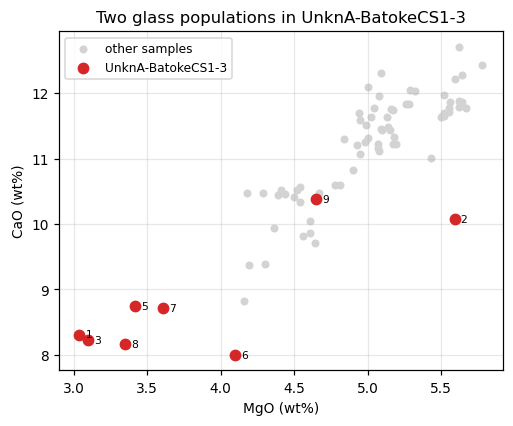

              SiO2        Al2O3          FeO         MgO          CaO        Na2O         K2O      
              mean count   mean count   mean count  mean count   mean count  mean count  mean count
A (high-Si)  48.90     6  17.71     6  10.25     6  3.44     6   8.36     6  5.22     6  2.39     6
B (low-Si)   45.65     2  16.51     2  10.09     2  5.12     2  10.23     2  6.52     2  2.20     2


In [29]:
bat = smp[(smp["sample"] == "UnknA-BatokeCS1-3") & smp.keep]
fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.scatter(smp.loc[smp.keep & (smp["sample"] != "UnknA-BatokeCS1-3"), "MgO"],
           smp.loc[smp.keep & (smp["sample"] != "UnknA-BatokeCS1-3"), "CaO"],
           s=18, c="lightgrey", label="other samples")
ax.scatter(bat.MgO, bat.CaO, s=45, c="tab:red", zorder=3, label="UnknA-BatokeCS1-3")
for _, r in bat.iterrows():
    ax.annotate(int(r.spot), (r.MgO, r.CaO), fontsize=7, xytext=(4, -2), textcoords="offset points")
ax.set(xlabel="MgO (wt%)", ylabel="CaO (wt%)", title="Two glass populations in UnknA-BatokeCS1-3")
ax.legend(fontsize=8); ax.grid(alpha=.3)
if SAVE: fig.savefig(FIG / "fig04_batoke_populations.png")
plt.show()

bat_grp = np.where(bat.MgO > 4.2, "B (low-Si)", "A (high-Si)")
print(bat.groupby(bat_grp)[["SiO2", "Al2O3", "FeO", "MgO", "CaO", "Na2O", "K2O"]]
      .agg(["mean", "count"]).round(2).to_string())

**Flow1-1 is one glass.** No oxide separates the two runs by more than the 2SD of the pooled spots, so the two nine-spot sequences sample the same population and are pooled (n = 17 after filtering, the tightest uncertainties here).

Worth one sentence in the report though: six of ten oxides differ between the runs by more than the **2SE** of the first run, by 0.3–5 %. The SiO₂ and Al₂O₃ offsets match the session drift over the intervening hour in both sign and size (−0.3 %, −0.4 %); MgO, CaO and K₂O do not. So 2SE on nine spots *understates* the true reproducibility of a sample average — a second visit to the same glass an hour later does not reproduce within 2SE. Quote 2SE as the statistical uncertainty on the mean, but do not claim differences between samples smaller than a few percent are real.

**BatokeCS1-3 is two glasses.** Spots 2, 4 and 9 sit at ~45.6 wt% SiO₂, 5.1 wt% MgO and 10.3 wt% CaO; spots 1, 3, 5, 6, 7 and 8 at ~48.9 wt% SiO₂, 3.4 wt% MgO and 8.4 wt% CaO. The gap is many times the spot-to-spot scatter of any other sample, and the two groups differ in the opposite sense to crystal contamination (higher MgO *and* higher CaO together, rather than one at the expense of the other), so this is two glass chips under one sample name.

Spot 4 was already removed for its 102.5 wt% total, which leaves the low-SiO₂ group with **only two spots — below the three-spot minimum**. It is therefore reported as two individual analyses, not as an average with a 2SE that two points cannot support, and the high-SiO₂ group is averaged normally (n = 6). Averaging all eight would have produced a composition matching neither chip.

## 8. Sample averages

n, mean, 2SD (spread of the spots) and 2SE (uncertainty on the mean) per sample per oxide, on the kept spots only, minimum n = 3.

In [30]:
smp["group"] = smp["sample"]
smp.loc[(smp["sample"] == "UnknA-BatokeCS1-3"), "group"] = np.where(
    smp.loc[(smp["sample"] == "UnknA-BatokeCS1-3"), "MgO"] > 4.2,
    "UnknA-BatokeCS1-3_B", "UnknA-BatokeCS1-3_A")

avg = summarize(smp[smp.keep], OX, "group")
print("samples with n < 3 on any oxide:", avg.loc[avg.n < 3, "group"].unique().tolist() or "none")

table = avg.pivot(index="group", columns="oxide", values="mean").reindex(columns=OX)
table.insert(0, "n", avg.groupby("group").n.max())
table["Total"] = smp[smp.keep].groupby("group").Total.mean()
print("\nmean composition (wt%)"); print(table.round(2).to_string())
print("\n2SE (wt%)")
print(avg.pivot(index="group", columns="oxide", values="2SE").reindex(columns=OX).round(3).to_string())

samples with n < 3 on any oxide: ['UnknA-BatokeCS1-3_B']

mean composition (wt%)
oxide                 n   SiO2  TiO2  Al2O3    FeO   MnO   MgO    CaO  Na2O   K2O  P2O5   SO3    Cl     F   Total
group                                                                                                            
1982-CS2-L3A          9  45.83  3.94  14.98  13.46  0.21  4.97  11.00  3.25  1.73  0.67  0.04  0.12  0.13  100.33
1982-CS2-L5B          9  45.99  3.83  14.82  13.82  0.25  4.44   9.70  4.86  2.05  0.74  0.04  0.13  0.19  100.87
UnknA-BatokeCS1-3_A   6  48.90  3.09  17.71  10.25  0.17  3.44   8.36  5.22  2.39  1.26  0.02  0.07  0.25  101.13
UnknA-BatokeCS1-3_B   2  45.65  3.10  16.51  10.09  0.15  5.12  10.23  6.52  2.20  1.19  0.02  0.39  0.24  101.40
UnknA-C21             8  44.76  3.78  15.24  12.59  0.24  4.41  10.48  4.84  2.18  1.00  0.11  0.13  0.16   99.91
UnknA-C22-PS1-L2      9  46.23  3.58  14.73  12.12  0.19  5.58  11.79  4.05  1.25  0.54  0.04  0.08  0.13  100.32
UnknA-C

## 9. Low-concentration oxides against detection limits

From the per-analysis D.L.(ppm) in `_all`. An oxide reported at less than ~3× its detection limit is not quantitative regardless of how well it averages.

In [31]:
EL = {"SO3": "S", "Cl": "Cl", "F": "F", "P2O5": "P", "MnO": "Mn", "K2O": "K", "TiO2": "Ti"}
dl = intens.groupby("element")["dl_ppm"].mean()

chk = pd.DataFrame({"mean_wt%": smp.loc[smp.keep, list(EL)].mean(),
                    "DL_ppm": [dl[EL[o]] for o in EL],
                    "2RSD%_VG2": [prec_w.loc[o, "VG2"] for o in EL]})
chk["x_DL"] = chk["mean_wt%"] * 1e4 / chk.DL_ppm
chk["spots_below_DL"] = [(smp.loc[smp.keep, o] * 1e4 < dl[EL[o]]).sum() for o in EL]
chk["?-flagged"] = [int((intens.element == EL[o] & pd.Series(True)).sum()) if False else
                    int(intens[(intens.element == EL[o]) & intens.flagged].shape[0]) for o in EL]
# reportable only if comfortably above the detection limit AND reproducible
chk["reportable"] = np.where((chk.x_DL > 5) & (chk["2RSD%_VG2"] < 50), "yes",
                    np.where(chk.x_DL <= 5, "no - at detection limit", "no - not reproducible"))
print(chk.round(2).to_string())
print("\nanalyses (of 105) carrying a JEOL '?' count-statistics flag, by element:")
print(intens[intens.flagged].element.value_counts().to_string())

      mean_wt%  DL_ppm  2RSD%_VG2    x_DL  spots_below_DL  ?-flagged               reportable
SO3       0.05  111.70       5.16    4.17               2         42  no - at detection limit
Cl        0.13   45.40      31.00   27.78               0          1                      yes
F         0.13  371.35     150.17    3.46               6         65  no - at detection limit
P2O5      0.76  152.23      26.49   50.09               0         13                      yes
MnO       0.22  283.11      37.82    7.64               0          6                      yes
K2O       1.77   61.10       6.55  290.30               0          1                      yes
TiO2      3.53  126.93       2.30  278.16               0          6                      yes

analyses (of 105) carrying a JEOL '?' count-statistics flag, by element:
element
F     65
S     42
P     13
Mg    10
Mn     6
Ti     6
Fe     4
Cl     1
K      1


Reportability rule: an oxide is quantitative only if the sample mean is **more than 5× the detection limit** and the independent standard reproduces it to better than 50 % 2RSD.

* **Reportable:** TiO₂, K₂O (both ~280× DL, 2–7 % 2RSD), P₂O₅ (50× DL), Cl (28× DL) and MnO (7.6× DL). Cl, P₂O₅ and MnO carry 2RSD of 26–38 %, so they are quoted with that uncertainty rather than to three decimals.
* **Not reportable: F and SO₃.** Both sit at 3–4× their detection limit in these basalts. F is additionally hopeless: 150 % 2RSD on VG-2, six spots below the detection limit, calibrated on KE3 — a rhyolitic glass that loses alkalis under the beam — and with no independent reference value in `Standards.xlsx`. The JEOL count-statistics flag confirms it from the instrument side: **65 of 105 analyses carry a `?` on F and 42 on S**, against 1 for Cl and K.

Both are kept in the spot table flagged as "detected, below quantification" rather than dropped or zeroed.

## 10. Save

In [32]:
if SAVE:
    smp.to_csv(OUT / "glass_spots_flagged.csv", index=False)      # all 81 spots, with keep/fail columns
    avg.to_csv(OUT / "glass_sample_averages.csv", index=False)    # n, mean, 2SD, 2RSD%, 2SE per group
    prec.to_csv(OUT / "glass_precision.csv", index=False)
    acc.to_csv(OUT / "glass_accuracy.csv", index=False)
    qt.to_csv(OUT / "glass_qtest_flags.csv", index=False)
print("\n".join(sorted(p.name for p in OUT.glob("glass_*.csv"))))
print("\n".join(sorted(p.name for p in FIG.glob("*.png"))))

glass_accuracy.csv
glass_precision.csv
glass_qtest_flags.csv
glass_sample_averages.csv
glass_spots_flagged.csv
fig01_drift_glass.png
fig02_accuracy_vs_precision_glass.png
fig03_totals_glass.png
fig04_batoke_populations.png


## Carry into the report

| | |
|---|---|
| Precision (session, VG-2) | 1–3 % 2RSD on majors; 25–30 % on Cl and P₂O₅; >100 % on F |
| Accuracy (VG-2, independent) | <1 % on SiO₂, TiO₂, Al₂O₃, FeO; **MgO +6 %**, CaO +1.6 % — both beyond 2SD |
| Drift | SiO₂ −1.5 %, Al₂O₃ −2–3 % over 6 h in both standards, within 2RSD → **no correction applied**, tested and justified |
| Spots removed | 6 of 81: one clinopyroxene (No. 49), five totals >102 wt% |
| Populations | Flow1-1 = one glass (18 spots pooled); BatokeCS1-3 = two glasses, reported separately |
| Not quantitative | F, SO₃ |

Open item for 02: the same MgO question should be asked of the olivine session — if MgO reads high there too, it is the Mg calibration; if not, it is specific to the glass session.